In [13]:
# Re-create processed dataset from original Sample Dataset.csv, then display key tables.
import pandas as pd, numpy as np, os
from datetime import datetime, timedelta
np.random.seed(42)
INPUT = "C:/Users/kajal/Downloads/Sample Dataset.csv"
df = pd.read_csv(INPUT, low_memory=False)






In [15]:
print(df.head())
print(df.columns)

  Lead ID Counselor        Sales Stage  \
0   L0001    Deepak  Intro Discussions   
1   L0002   Cynthia       Prescheduled   
2   L0003    Farhan   Cost Discussions   
3   L0004     Grace           Enrolled   
4   L0005     Harsh           Enrolled   

  Notes for your reference [Should be detailed History]   Country  \
0                                Asked to call later      Nigeria   
1                           Needs visa clarification     Zimbabwe   
2                            No response on WhatsApp     Zimbabwe   
3                     Considering other universities      Nigeria   
4                          Wants placement guarantee       Zambia   

  Fee Interest Status/Temperament Stage Update Date Last Conversation Date  
0       $1,800             Active               NaN                    NaN  
1       $2,000           Enrolled               NaN                    NaN  
2       $1,800            Pending               NaN                    NaN  
3       $2,000          

In [19]:
Index(['Lead ID', 'Counselor', 'Sales Stage', 'Notes',
       'Country', 'Fee Interest', 'Status/Temperament',
       'Stage Update Date', 'Last Conversation Date'],
      dtype='object')

NameError: name 'Index' is not defined

In [21]:
# Step 4: clean & simulate dates

# 1. Convert existing date columns (if they have anything) into real datetime objects
df['Stage Update Date'] = pd.to_datetime(df['Stage Update Date'], errors='coerce')
df['Last Conversation Date'] = pd.to_datetime(df['Last Conversation Date'], errors='coerce')

# 2. Define "today" for calculations
today = datetime(2025, 9, 15)  # pretend today is Sep 15, 2025

# 3. Funnel order (to bias simulated dates)
stages_order = [
    "Untouched", "Prescheduled", "Intro Discussions", "Cost Discussions",
    "Pitched", "Pitched & Processed", "Enrolled", "Program Dead"
]
stage_bias = {stage: i for i, stage in enumerate(stages_order)}

# 4. Simulate Stage Update Date where missing
sim_dates = []
for _, row in df.iterrows():
    if pd.isna(row['Stage Update Date']):
        bias = stage_bias.get(row['Sales Stage'], 3)   # earlier stages = older dates
        days = max(1, int(abs(np.random.normal(loc=20 - bias*2, scale=10))))
        sim_date = today - timedelta(days=days)
        sim_dates.append(sim_date)
    else:
        sim_dates.append(row['Stage Update Date'])

df['Stage Update Date (Sim)'] = sim_dates

# 5. Simulate Last Conversation Date where missing
last_conv = []
for _, row in df.iterrows():
    if pd.isna(row['Last Conversation Date']):
        delta = np.random.randint(0, 6)  # assume conversation happened 0–5 days before update
        last_conv.append(row['Stage Update Date (Sim)'] - timedelta(days=delta))
    else:
        last_conv.append(row['Last Conversation Date'])

df['Last Conversation Date (Sim)'] = last_conv

# 6. Calculate "Days in Stage" and stuck flag
df['Days In Stage'] = (today - df['Stage Update Date (Sim)']).dt.days
df['Stuck (>7 days)'] = df['Days In Stage'] > 7

print(df[['Lead ID','Sales Stage','Stage Update Date (Sim)','Last Conversation Date (Sim)','Days In Stage','Stuck (>7 days)']].head(10))


  Lead ID        Sales Stage Stage Update Date (Sim)  \
0   L0001  Intro Discussions              2025-08-26   
1   L0002       Prescheduled              2025-08-30   
2   L0003   Cost Discussions              2025-08-26   
3   L0004           Enrolled              2025-08-23   
4   L0005           Enrolled              2025-09-10   
5   L0006   Cost Discussions              2025-09-04   
6   L0007            Pitched              2025-08-19   
7   L0008           Enrolled              2025-08-31   
8   L0009           Enrolled              2025-09-12   
9   L0010          Untouched              2025-08-21   

  Last Conversation Date (Sim)  Days In Stage  Stuck (>7 days)  
0                   2025-08-21             20             True  
1                   2025-08-28             16             True  
2                   2025-08-26             20             True  
3                   2025-08-20             23             True  
4                   2025-09-10              5            F

In [23]:
# Step 5: Create a short AI-style summary for each lead

def create_summary(row, max_chars=200):
    notes = str(row.get('Notes', '')).replace('\n', ' ').strip()
    snippet = notes[:max_chars]
    summary = (
        f"Lead {row['Lead ID']} | Stage: {row['Sales Stage']} | "
        f"Country: {row.get('Country','NA')} | FeeInterest: {row.get('Fee Interest','NA')} | "
        f"Status: {row.get('Status/Temperament','NA')} | DaysInStage: {row['Days In Stage']}\n"
        f"NotesSummary: {snippet}"
    )
    return summary

df['AI_Summary'] = df.apply(create_summary, axis=1)

print(df[['Lead ID','Counselor','Sales Stage','Days In Stage','Stuck (>7 days)','AI_Summary']].head(5))


  Lead ID Counselor        Sales Stage  Days In Stage  Stuck (>7 days)  \
0   L0001    Deepak  Intro Discussions             20             True   
1   L0002   Cynthia       Prescheduled             16             True   
2   L0003    Farhan   Cost Discussions             20             True   
3   L0004     Grace           Enrolled             23             True   
4   L0005     Harsh           Enrolled              5            False   

                                          AI_Summary  
0  Lead L0001 | Stage: Intro Discussions | Countr...  
1  Lead L0002 | Stage: Prescheduled | Country: Zi...  
2  Lead L0003 | Stage: Cost Discussions | Country...  
3  Lead L0004 | Stage: Enrolled | Country: Nigeri...  
4  Lead L0005 | Stage: Enrolled | Country: Zambia...  


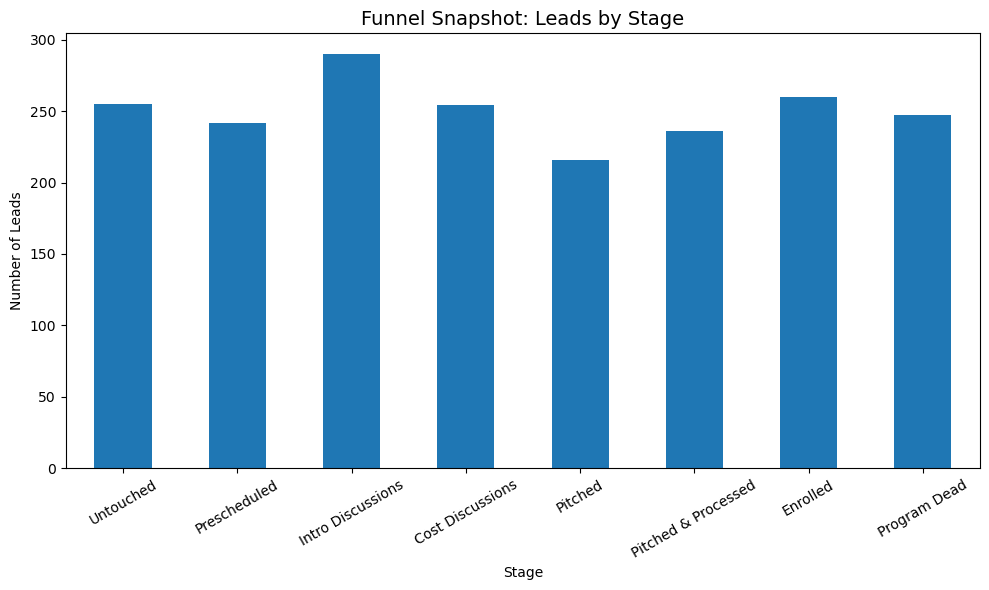

In [25]:
import matplotlib.pyplot as plt

# Step 6a: Funnel snapshot - count leads by stage
stage_counts = df['Sales Stage'].value_counts().reindex([
    "Untouched", "Prescheduled", "Intro Discussions", "Cost Discussions",
    "Pitched", "Pitched & Processed", "Enrolled", "Program Dead"
])

plt.figure(figsize=(10,6))
stage_counts.plot(kind='bar')

plt.title("Funnel Snapshot: Leads by Stage", fontsize=14)
plt.xlabel("Stage")
plt.ylabel("Number of Leads")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


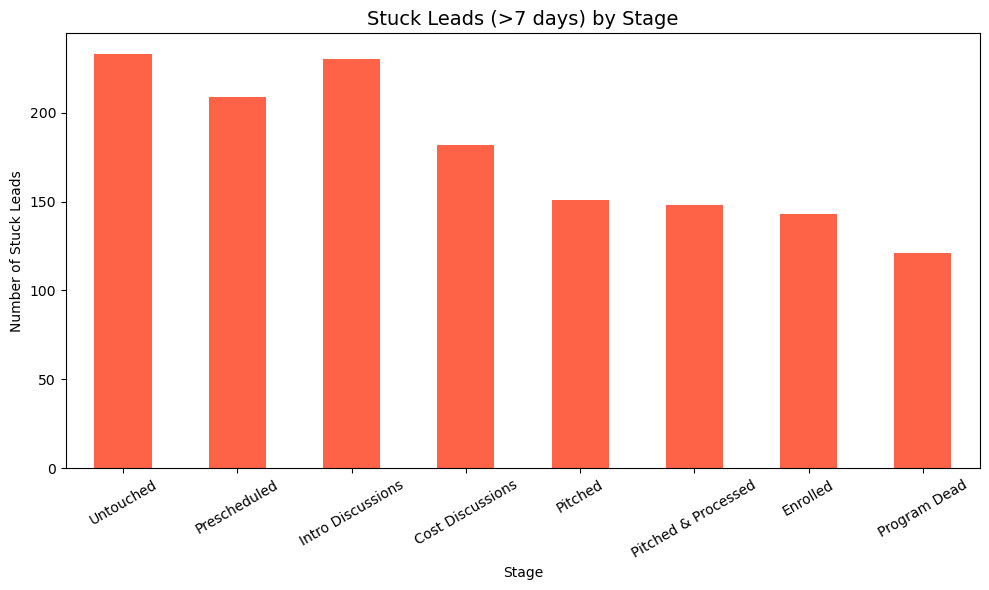

In [27]:
# Step 6b: Stuck leads by stage (>7 days)
stuck_counts = df[df['Stuck (>7 days)']].groupby('Sales Stage')['Lead ID'].count().reindex([
    "Untouched", "Prescheduled", "Intro Discussions", "Cost Discussions",
    "Pitched", "Pitched & Processed", "Enrolled", "Program Dead"
])

plt.figure(figsize=(10,6))
stuck_counts.plot(kind='bar', color='tomato')

plt.title("Stuck Leads (>7 days) by Stage", fontsize=14)
plt.xlabel("Stage")
plt.ylabel("Number of Stuck Leads")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


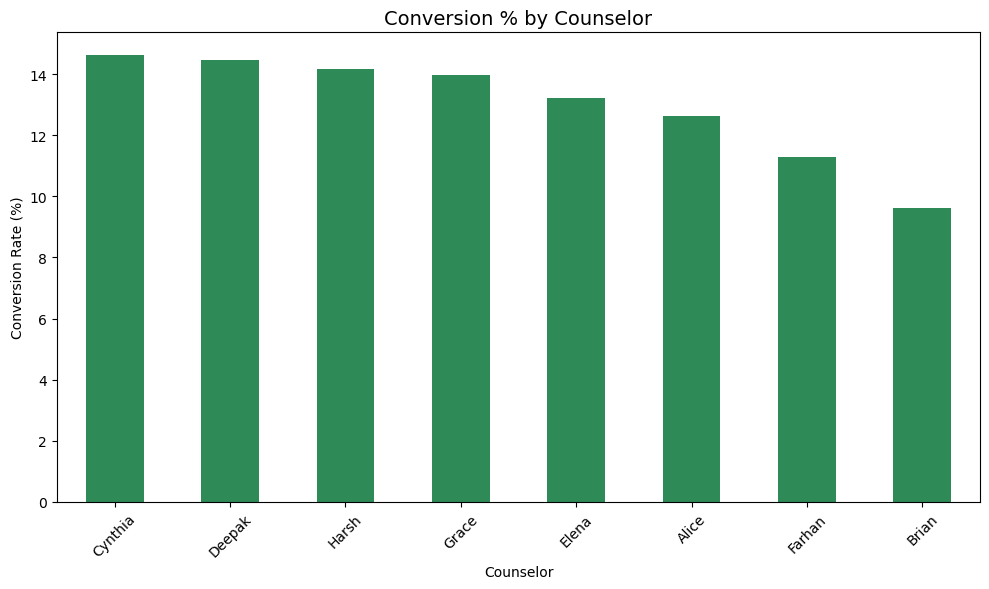

In [29]:
# Step 6c: Conversion % by counselor
# A counselor's conversion = (Enrolled leads / Total leads assigned) * 100

counselor_totals = df.groupby('Counselor')['Lead ID'].count()
counselor_enrolled = df[df['Sales Stage'] == 'Enrolled'].groupby('Counselor')['Lead ID'].count()

conversion_rate = (counselor_enrolled / counselor_totals * 100).fillna(0).sort_values(ascending=False)

plt.figure(figsize=(10,6))
conversion_rate.plot(kind='bar', color='seagreen')

plt.title("Conversion % by Counselor", fontsize=14)
plt.xlabel("Counselor")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [31]:
df.to_csv("C:/Users/kajal/Downloads/processed_leads.csv", index=False)
